# 04 - SHAP ინტერპრეტაცია

ამ ნოუთბუქის მიზანია ვუპასუხოთ ნაშრომის ძირეულ კითხვას: **რა განაპირობებს ფეხბურთელის ფასს?**

SHAP (SHapley Additive exPlanations) გვაძლევს საშუალებას ვიხილოთ:
1. **გლობალური მნიშვნელობა** - რომელი feature მოქმედებს ყველაზე მეტად მთლიან dataset-ზე
2. **ლოკალური ახსნა** - კონკრეტული მოთამაშისთვის, რომელი ფაქტორი როგორ მოქმედებდა მის ფასზე
3. **ბაზრის ანომალიები** - მოთამაშეები, რომელთა რეალური ფასი მნიშვნელოვნად განსხვავდება პროგნოზისგან

## 1. იმპორტები და მოდელის ხელახლა სწავლება

SHAP-ისთვის გვჭირდება საუკეთესო მოდელი (LightGBM) იმავე train/test split-ით.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import lightgbm as lgb

plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('../data/raw/merged_raw.csv')
print(f"Shape: {df.shape}")

Shape: (2111, 277)


## 2. Feature Engineering (03-ის გამეორება)

იგივე feature-ები რაც მოდელირების ეტაპზე გამოვიყენეთ.

In [25]:
df['log_market_value'] = np.log1p(df['market_value_in_eur'])
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')

if 'Gls' in df.columns and 'Ast' in df.columns:
    df['G_A'] = df['Gls'].fillna(0) + df['Ast'].fillna(0)
if 'xG' in df.columns and 'xAG' in df.columns:
    df['xG_xAG'] = df['xG'].fillna(0) + df['xAG'].fillna(0)

df['Age_squared'] = df['Age'] ** 2
df['Age_from_peak'] = abs(df['Age'] - 23)

if 'league' not in df.columns:
    league_map = {
        'eng Premier League': 'Premier League',
        'es La Liga': 'La Liga',
        'de Bundesliga': 'Bundesliga',
        'it Serie A': 'Serie A',
        'fr Ligue 1': 'Ligue 1'
    }
    df['league'] = df['Comp'].map(league_map)

numeric_features = [
    'Gls', 'Ast', 'G_A', 'xG', 'xAG', 'xG_xAG',
    'Sh', 'SoT', 'KP', 'PrgC', 'PrgP', 'PrgR',
    'Tkl', 'Int', 'Blocks',
    'Age', 'Age_squared', 'Age_from_peak',
    'height_in_cm'
]
categorical_features = ['position', 'league', 'foot']

numeric_features = [f for f in numeric_features if f in df.columns]
categorical_features = [f for f in categorical_features if f in df.columns]
all_features = numeric_features + categorical_features
target = 'log_market_value'

df_model = df[all_features + [target] + ['Player']].dropna(subset=[target]).copy()

print(f"Features: {len(all_features)}, Players: {len(df_model)}")

Features: 22, Players: 2111


## 3. Train/Test გაყოფა და Preprocessing

In [26]:
X = df_model[all_features]
y = df_model[target]
players = df_model['Player']

X_train, X_test, y_train, y_test, players_train, players_test = train_test_split(
    X, y, players, test_size=0.2, random_state=42
)

for col in numeric_features:
    X_train[col] = X_train[col].fillna(X_train[col].median())
    X_test[col] = X_test[col].fillna(X_train[col].median())
for col in categorical_features:
    X_train[col] = X_train[col].fillna('Unknown')
    X_test[col] = X_test[col].fillna('Unknown')

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

feature_names = (numeric_features +
                  list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)))

print(f"Processed features: {len(feature_names)}")

Processed features: 32


## 4. LightGBM მოდელის სწავლება

In [28]:
X_train_proc = pd.DataFrame(X_train_proc, columns=feature_names)
X_test_proc = pd.DataFrame(X_test_proc, columns=feature_names)

model = lgb.LGBMRegressor(
    n_estimators=300, learning_rate=0.05,
    max_depth=6, random_state=42, n_jobs=-1, verbose=-1
)
model.fit(X_train_proc, y_train)

train_score = model.score(X_train_proc, y_train)
test_score = model.score(X_test_proc, y_test)
print(f"Train R2: {train_score:.4f}")
print(f"Test R3:  {test_score:.4f}")

Train R2: 0.8579
Test R3:  0.5621


## 5. SHAP მნიშვნელობების გამოთვლა

TreeExplainer-ი ოპტიმიზებულია tree-based მოდელებისთვის (LightGBM, XGBoost, Random Forest) და ზუსტად ითვლის SHAP მნიშვნელობებს.

In [29]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_proc)

X_test_df = pd.DataFrame(X_test_proc, columns=feature_names)

print(f"SHAP values shape: {shap_values.shape}")
print("SHAP მნიშვნელობები გამოთვლილია")

SHAP values shape: (423, 32)
SHAP მნიშვნელობები გამოთვლილია


## 6. გლობალური Feature Importance - Summary Plot

ეს გრაფიკი გვიჩვენებს, რომელი feature მოქმედებს ყველაზე მეტად მოდელის გადაწყვეტილებებზე მთლიან test set-ზე.

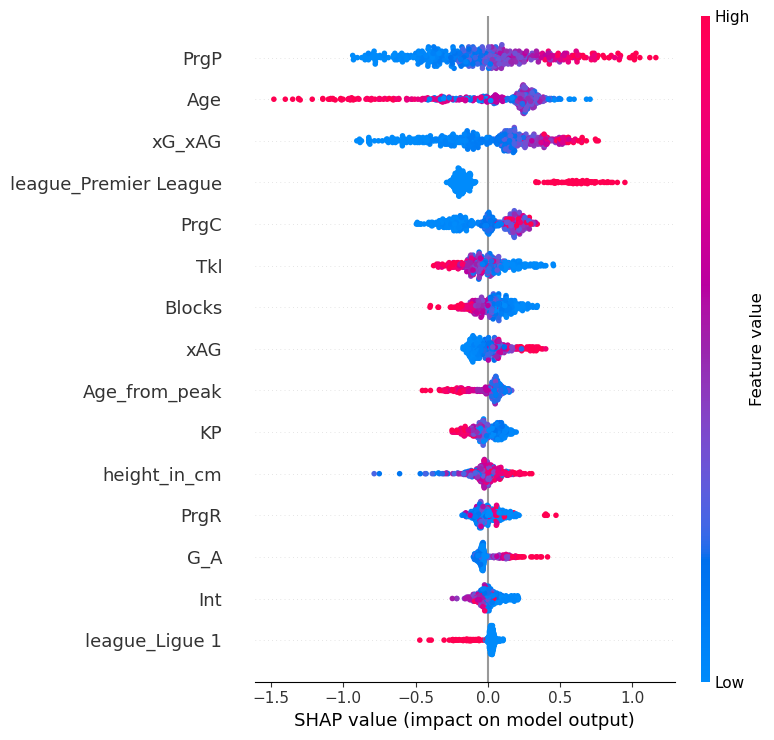

In [30]:
plt.figure()
shap.summary_plot(shap_values, X_test_df, max_display=15, show=False)
plt.tight_layout()
plt.savefig('../data/processed/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Feature Importance — Bar Chart

საშუალო აბსოლუტური SHAP მნიშვნელობა თითო feature-ისთვის.

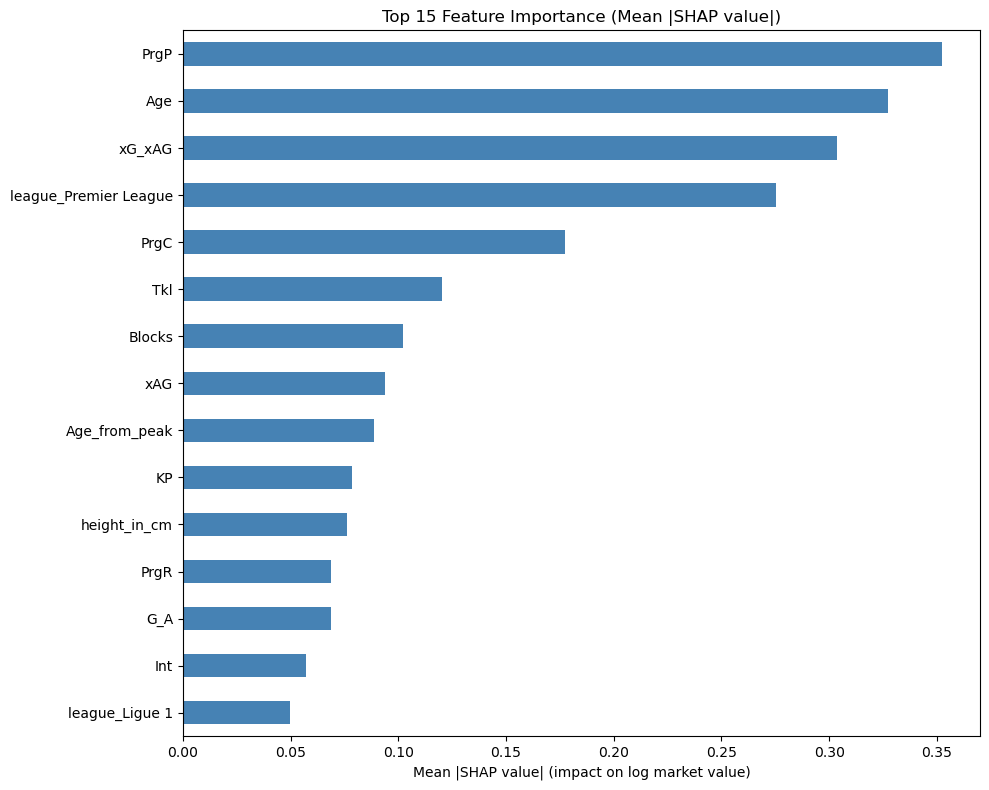

PrgP                     0.3524
Age                      0.3275
xG_xAG                   0.3038
league_Premier League    0.2754
PrgC                     0.1774
Tkl                      0.1202
Blocks                   0.1023
xAG                      0.0936
Age_from_peak            0.0887
KP                       0.0784
height_in_cm             0.0762
PrgR                     0.0686
G_A                      0.0686
Int                      0.0574
league_Ligue 1           0.0497


In [31]:
mean_abs_shap = pd.Series(
    np.abs(shap_values).mean(axis=0), index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
mean_abs_shap.head(15).plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importance (Mean |SHAP value|)')
plt.xlabel('Mean |SHAP value| (impact on log market value)')
plt.tight_layout()
plt.savefig('../data/processed/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(mean_abs_shap.head(15).round(4).to_string())

## 8. Dependence Plot - ასაკის გავლენა

ვამოწმებთ ზუსტად როგორ მოქმედებს ასაკი ღირებულებაზე SHAP-ის მიხედვით

<Figure size 1000x600 with 0 Axes>

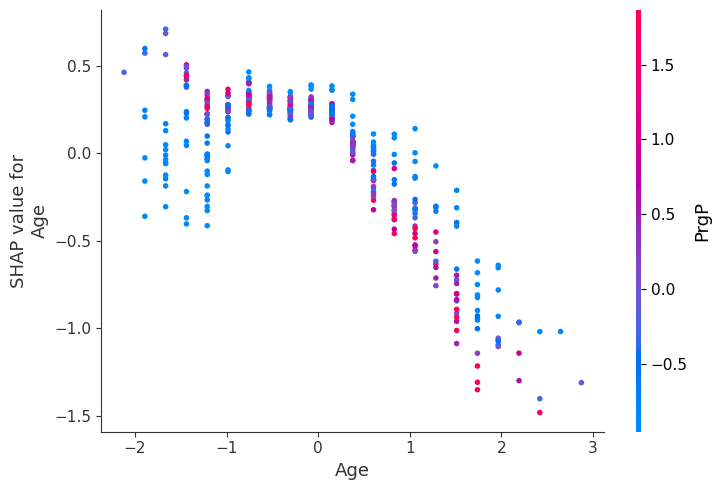

In [32]:
plt.figure()
shap.dependence_plot('Age', shap_values, X_test_df, show=False)
plt.tight_layout()
plt.savefig('../data/processed/shap_age_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. ბაზრის ანომალიების ანალიზი

ვპოულობთ მოთამაშეებს, რომელთა **რეალური ფასი** მნიშვნელოვნად განსხვავდება მოდელის **პროგნოზისგან**. ეს არის შემთხვევები, სადაც ბაზარი შესაძლოა ირაციონალურია - ან მოდელს არ აქვს ხელმისაწვდომი მნიშვნელოვანი ინფორმაცია (ბრენდი, ტრავმები, კონტრაქტი).

In [33]:
y_pred = model.predict(X_test_proc)

anomalies = pd.DataFrame({
    'player': players_test.values,
    'actual_value_M': np.expm1(y_test.values) / 1e6,
    'predicted_value_M': np.expm1(y_pred) / 1e6,
})
anomalies['diff_M'] = anomalies['actual_value_M'] - anomalies['predicted_value_M']
anomalies['diff_pct'] = (anomalies['diff_M'] / anomalies['predicted_value_M']) * 100

# ყველაზე overvalued - ბაზარი მათ მეტს უხდის ვიდრე სტატისტიკა ამართლებს
overvalued = anomalies.sort_values('diff_M', ascending=False).head(10)

# ყველაზე undervalued - ბაზარი მათ ნაკლებს უხდის ვიდრე სტატისტიკა ამართლებს
undervalued = anomalies.sort_values('diff_M', ascending=True).head(10)

print("=== TOP 10 OVERVALUED (ბაზარი > მოდელის პროგნოზი) ===")
print(overvalued[['player', 'actual_value_M', 'predicted_value_M', 'diff_M']].round(1).to_string(index=False))

print("\n=== TOP 10 UNDERVALUED (ბაზარი < მოდელის პროგნოზი) ===")
print(undervalued[['player', 'actual_value_M', 'predicted_value_M', 'diff_M']].round(1).to_string(index=False))

anomalies.to_csv('../data/processed/market_anomalies.csv', index=False)

=== TOP 10 OVERVALUED (ბაზარი > მოდელის პროგნოზი) ===
               player  actual_value_M  predicted_value_M  diff_M
      Jude Bellingham           180.0               25.7   154.3
  Aurélien Tchouaméni           100.0               12.1    87.9
Khvicha Kvaratskhelia            90.0               11.9    78.1
          Désiré Doué            90.0               23.8    66.2
        Ronald Araújo            70.0                7.7    62.3
              Rodrygo           110.0               51.6    58.4
        Willian Pacho            65.0               10.0    55.0
           João Neves            80.0               25.5    54.5
          Xavi Simons            80.0               28.3    51.7
  Aleksandar Pavlovic            55.0                8.7    46.3

=== TOP 10 UNDERVALUED (ბაზარი < მოდელის პროგნოზი) ===
               player  actual_value_M  predicted_value_M  diff_M
      Ademola Lookman            60.0              114.0   -54.0
     Marcus Tavernier            18.0        

## 10. ლოკალური ახსნა - კონკრეტული მოთამაშის Waterfall Plot

ერთი კონკრეტული მოთამაშისთვის ვაჩვენებთ ზუსტად რომელმა feature-მა რა გავლენა იქონია მის საბაზრო ღირებულებაზე.

მოთამაშე: Jude Bellingham
რეალური ღირებულება:   €180.0M
პროგნოზირებული ღირებულება: €25.7M


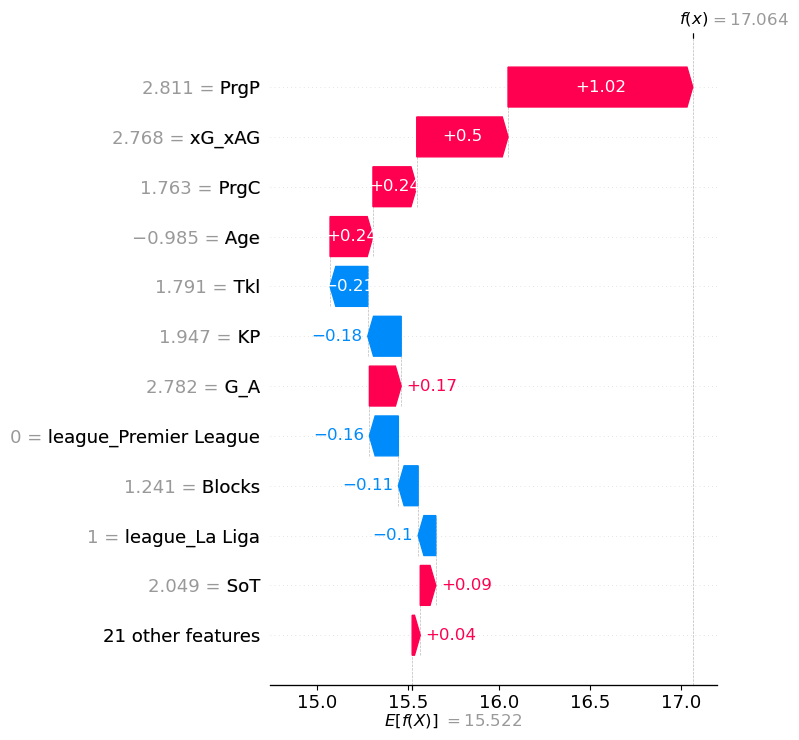

In [34]:
# ავირჩიოთ ყველაზე overvalued მოთამაშე ვიზუალიზაციისთვის
idx = anomalies['diff_M'].idxmax()
player_name = anomalies.loc[idx, 'player']

print(f"მოთამაშე: {player_name}")
print(f"რეალური ღირებულება:   €{anomalies.loc[idx, 'actual_value_M']:.1f}M")
print(f"პროგნოზირებული ღირებულება: €{anomalies.loc[idx, 'predicted_value_M']:.1f}M")

plt.figure()
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[idx],
        base_values=explainer.expected_value,
        data=X_test_df.iloc[idx].values,
        feature_names=feature_names
    ),
    max_display=12, show=False
)
plt.tight_layout()
plt.savefig('../data/processed/shap_waterfall_example.png', dpi=150, bbox_inches='tight')
plt.show()

## შედეგების შეჯამება

### Feature Importance (SHAP)

| რანგი | Feature | მნიშვნელობა |
|-------|---------|--------------|
| 1 | PrgP (Progressive Passes) | 0.352 |
| 2 | Age | 0.328 |
| 3 | xG_xAG | 0.304 |
| 4 | league_Premier League | 0.275 |
| 5 | PrgC (Progressive Carries) | 0.177 |

**ძირეული დასკვნა:** ბაზარი ყველაზე მეტ ღირებულებას სძენს ბურთის
**პროგრესირებას შუა ველზე** (PrgP, PrgC) და **თავდასხმით პოტენციალს**
(xG_xAG), ხოლო **ლიგის პრესტიჟი** (Premier League-ში თამაში) დამოუკიდებელ
ფასობრივ ნამატს სძენს ამ სტატისტიკის მიღმა.

### ასაკის არაწრფივი გავლენა

SHAP dependence plot-ი ცალსახად ადასტურებს EDA-ში ნანახ პატერნს: ფასზე
ასაკის გავლენა **არაწრფივია** - ახალგაზრდობა (SHAP +0.4 to +0.7) ძირეულად
ზრდის ფასს, პიკ ასაკში (23-24 წელი) ეფექტი პლატოზე ჩერდება, ხოლო 28+
წლიდან ეფექტი მკვეთრად უარყოფითდება (SHAP up to -1.5). განსაკუთრებით
საინტერესო: **ახალგაზრდა + მაღალი PrgP** კომბინაცია (ანუ "ახალგაზრდა
შემოქმედებითი ვარსკვლავი" პროფილი) ბაზარზე ყველაზე მაღლა ფასდება.

### ბაზრის ანომალიები - სტატისტიკა vs რეალური ფასი

**ყველაზე "overvalued" მოთამაშეები** (ბაზარი >> მოდელის პროგნოზი):

| მოთამაშე | რეალური (€M) | პროგნოზი (M) | სხვაობა |
|----------|---------------|-----------------|---------|
| Jude Bellingham | 180.0 | 25.7 | +154.3 |
| Aurélien Tchouaméni | 100.0 | 12.1 | +87.9 |
| Khvicha Kvaratskhelia | 90.0 | 11.9 | +78.1 |

**ყველაზე "undervalued" მოთამაშეები** (ბაზარი << მოდელის პროგნოზი):

| მოთამაშე | რეალური (€M) | პროგნოზი (M) | სხვაობა |
|----------|---------------|-----------------|---------|
| Ademola Lookman | 60.0 | 114.0 | -54.0 |
| Marcus Tavernier | 18.0 | 65.2 | -47.2 |
| Antoine Semenyo | 40.0 | 76.0 | -36.0 |

**ინტერპრეტაცია:** "Overvalued" მოთამაშეები ხშირად ახალგაზრდა, მაღალი
ბრენდის/პოტენციალის მქონე ვარსკვლავები არიან (Bellingham, Kvaratskhelia,
Doue) - ბაზარი მათ მომავალ პოტენციალს და მარკეტინგულ ღირებულებას
აფასებს, რასაც დამოუკიდებლად სტატისტიკა ვერ ხსნის. "Undervalued"
მოთამაშეები კი საპირისპირო შემთხვევაა - მაღალი სტატისტიკური
ეფექტიანობა, თუმცა ნაკლებად პრესტიჟული კლუბი/ლიგა ან შემთხვევითი
ფორმის ეფექტი ამცირებს მათ საბაზრო ღირებულებას.

### საბოლოო დასკვნა

SHAP ანალიზი ადასტურებს, რომ ფეხბურთის ტრანსფერული ბაზარი მნიშვნელოვან
წილად ეფუძნება შემოწმებად სტატისტიკურ მაჩვენებლებს (პროგრესული მოქმედებები,
თავდასხმითი ეფექტიანობა, ასაკი), თუმცა კონკრეტული ანომალიების არსებობა
ცხადყოფს, რომ **ბრენდი, პოტენციალი და ლიგის კონტექსტი** წამყვან როლს
თამაშობს იქ, სადაც წმინდა სტატისტიკა საკმარისი ახსნა არ არის.